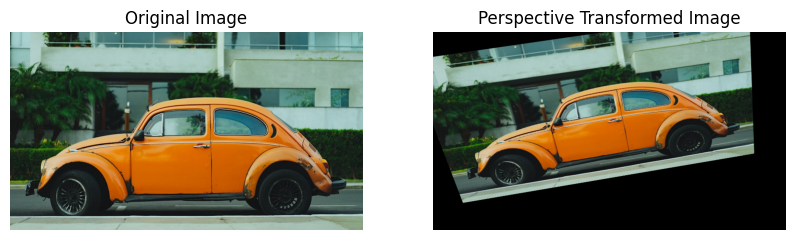

In [3]:
# Install libraries (only needed in Colab)
!pip install opencv-python matplotlib

import cv2
import numpy as np
from matplotlib import pyplot as plt
import urllib.request

# -------------------------------
# 1. Download sample image
# -------------------------------
image_url = "https://images.unsplash.com/photo-1489824904134-891ab64532f1?auto=format&fit=crop&w=800&q=80"

# Create a Request object with a User-Agent header to mimic a web browser
req = urllib.request.Request(
    image_url,
    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
)

# Open the URL with the request object and save the content
try:
    with urllib.request.urlopen(req) as response:
        with open("sample.jpg", "wb") as out_file:
            out_file.write(response.read())
except urllib.error.HTTPError as e:
    print(f"Error downloading image: {e}")
    print("Please check the image URL or try a different image source.")
    exit()

# -------------------------------
# 2. Read image
# -------------------------------
img = cv2.imread("sample.jpg")

if img is None:
    print("Error loading image. The image file might be corrupted or not exist.")
    exit()

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Get image size
rows, cols, ch = img.shape

# -------------------------------
# 3. Define Perspective Points
# -------------------------------

# Original image points
pts1 = np.float32([
    [50, 50],
    [400, 50],
    [50, 400],
    [400, 400]
])

# New transformed points
pts2 = np.float32([
    [10, 100],
    [350, 50],
    [100, 350],
    [400, 300]
])

# -------------------------------
# 4. Create Perspective Matrix
# -------------------------------
matrix = cv2.getPerspectiveTransform(pts1, pts2)

# Apply Perspective Transformation
transformed = cv2.warpPerspective(img, matrix, (cols, rows))

# Convert transformed image to RGB
transformed_rgb = cv2.cvtColor(transformed, cv2.COLOR_BGR2RGB)

# -------------------------------
# 5. Display images
# -------------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Perspective Transformed Image")
plt.imshow(transformed_rgb)
plt.axis('off')

plt.show()